# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

In [67]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

import spacy

## Load Data

In [106]:
import pandas as pd

# Load data
df = pd.read_csv(
    r'data/reviews.csv',
)

# Check the first few rows of the dataset
df.head()

,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Data Exploration
Exploratory Data Analysis (EDA) is a process of examining the dataset to gain insights and understand the underlying patterns, relationships, and trends.

In [107]:
# Check data information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              18442 non-null  int64
 1   Age                      18442 non-null  int64
 2   Title                    18442 non-null  str  
 3   Review Text              18442 non-null  str  
 4   Positive Feedback Count  18442 non-null  int64
 5   Division Name            18442 non-null  str  
 6   Department Name          18442 non-null  str  
 7   Class Name               18442 non-null  str  
 8   Recommended IND          18442 non-null  int64
dtypes: int64(4), str(5)
memory usage: 1.3 MB


In [70]:
# Statistical summary of numeric columns
df.describe(include=[np.number])

,Clothing ID,Age,Positive Feedback Count,Recommended IND
count,18442.000000,18442.000000,18442.000000,18442.000000
mean,954.896757,43.383635,2.697484,0.816235
std,141.571783,12.246264,5.942220,0.387303
min,2.000000,18.000000,0.000000,0.000000
25%,863.000000,34.000000,0.000000,1.000000
50%,952.000000,41.000000,1.000000,1.000000
75%,1078.000000,52.000000,3.000000,1.000000
max,1205.000000,99.000000,122.000000,1.000000


In [71]:
# Statistical summary of categorical and text columns
df.describe(include=['object', 'string'])

,Title,Review Text,Division Name,Department Name,Class Name
count,18442,18442,18442,18442,18442
unique,13142,18439,2,6,14
top,Love it!,I purchased this and another eva franco dress ...,General,Tops,Dresses
freq,129,2,11664,8713,5371


In [72]:
# check duplicates

if df.duplicated().sum() > 0:
    print('Duplicates found!')
else:
    print('No duplicates found.')


No duplicates found.


In [73]:
# Check null values
df.isnull().sum()

if df.isnull().sum().sum() > 0:
    print('Null values found!')
else:
    print('No null values found.')

No null values found.


In [74]:
# Check positive feedback count
df.sort_values(by='Positive Feedback Count', ascending=False).head(10)

,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
5689,1092,34,Beware if you're fuller in the chest,I loved the lace detailing all over this dress...,122,General,Dresses,Dresses,1
6112,986,43,Quality does not merit cost,"I generally don't write bad reviews, but there...",108,General,Jackets,Jackets,0
14992,1121,35,A navy trench-yes!,I am a big fan of trench coats and i love that...,99,General,Jackets,Outerwear,1
10393,1078,23,"Super flattering, beautiful dress",This is my favorite dress i've bought in the p...,98,General,Dresses,Dresses,1
12835,867,56,At least it's not a swing top! tts?,I loved the idea of the placement print around...,95,General,Tops,Knits,1
1655,1072,39,Another tiny success,Tiny are experts at making busy bohemian shirt...,94,General Petite,Dresses,Dresses,1
13539,864,23,Stunning but has fit issues,"This top is beautiful, the lace is sturdy and ...",93,General,Tops,Knits,1
7402,1094,37,Knock out!,I am a huge fan of absolutely everything tanvi...,89,General Petite,Dresses,Dresses,1
6827,1078,52,Fun spring colors but tricky on certain body t...,In the store i was immediately drawn to the bl...,87,General Petite,Dresses,Dresses,1
522,1087,52,Worth it,"I never buy anything at retailer full price, b...",84,General,Dresses,Dresses,1


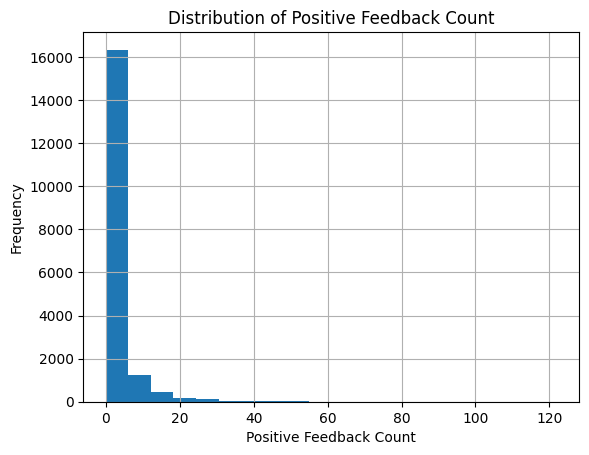

In [75]:
# Visualize the distribution of positive feedback count
df['Positive Feedback Count'].hist(bins=20)
plt.title('Distribution of Positive Feedback Count')
plt.xlabel('Positive Feedback Count')
plt.ylabel('Frequency')
plt.show()

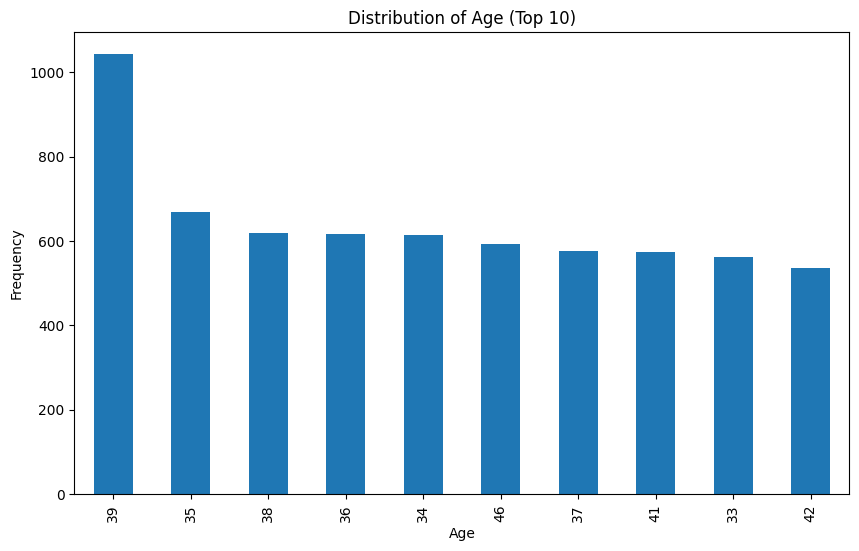

In [76]:
# Visualization of age distribution (top 10)
plt.figure(figsize=(10, 6))
df['Age'].value_counts().head(10).plot(kind='bar')
plt.title('Distribution of Age (Top 10)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

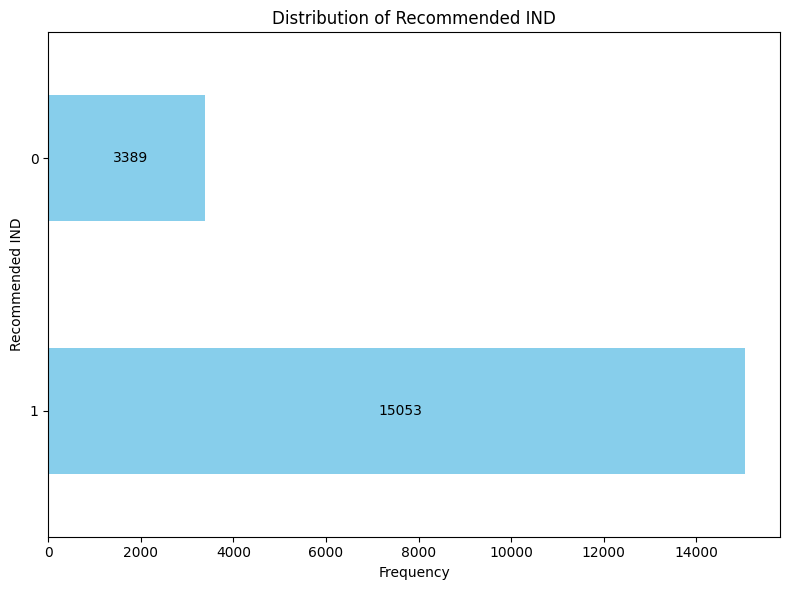

In [77]:
# Recommended IND Visualization
fig, ax = plt.subplots(figsize=(8, 6))
df['Recommended IND'].value_counts().plot(kind='barh', ax=ax, color='skyblue')
ax.set_title('Distribution of Recommended IND')
ax.set_ylabel('Recommended IND')
ax.set_xlabel('Frequency')
ax.bar_label(ax.containers[0], padding=3, label_type= 'center')
plt.tight_layout()
plt.show()

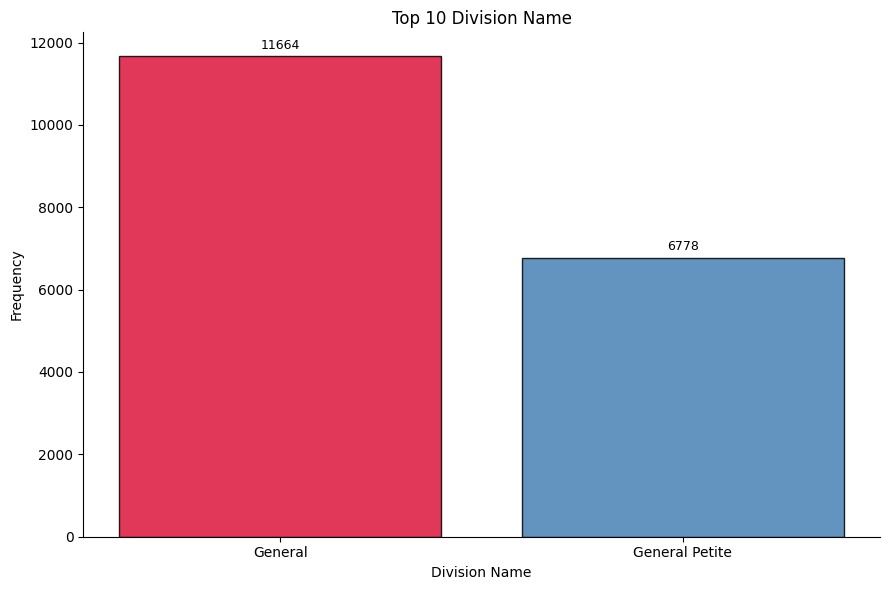

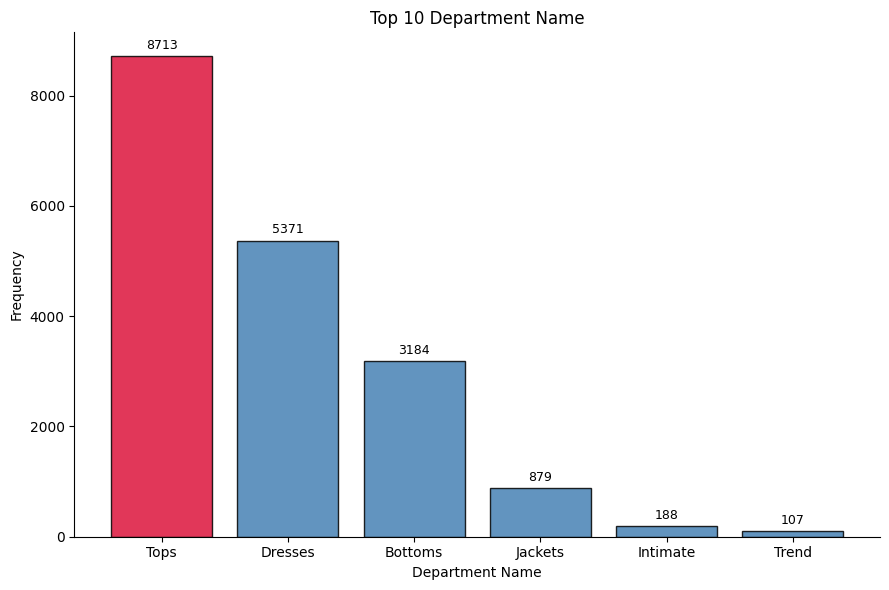

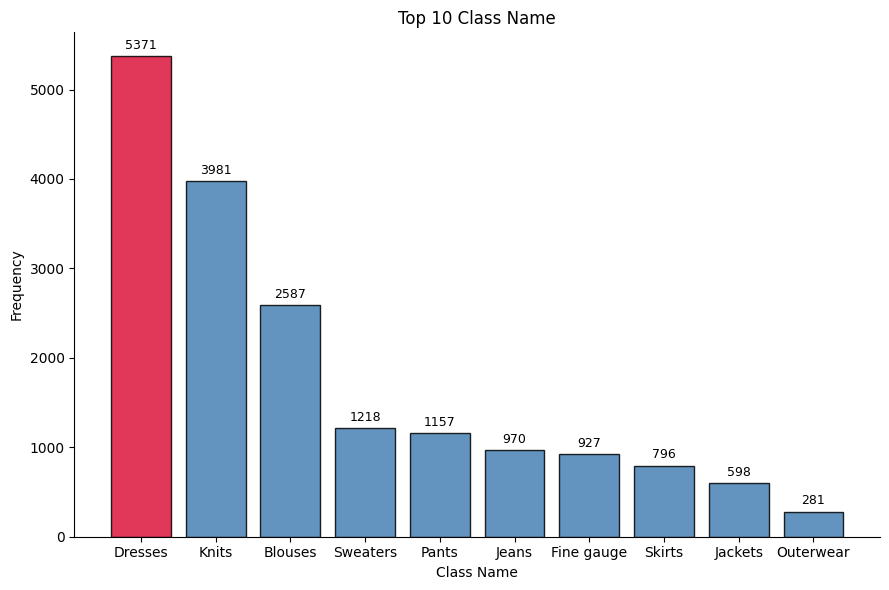

In [78]:
# Plot top 10 categories for each categorical feature

cat_list = ['Division Name', 'Department Name', 'Class Name']

for cat in cat_list:
    counts = df[cat].value_counts().nlargest(10)

    fig, ax = plt.subplots(figsize=(9, 6))

    colors = ['steelblue'] * len(counts)
    colors[0] = 'crimson'

    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black', alpha=0.85)

    ax.set_title(f'Top 10 {cat}')
    ax.set_xlabel(cat)
    ax.set_ylabel('Frequency')
    ax.bar_label(bars, padding=3, fontsize=9)

    ax.spines[['top', 'right']].set_visible(False)
    plt.xticks(ha='center')
    plt.tight_layout()
    plt.show()

## Preparing features (`X`) & target (`y`)

In [79]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [ ]:
# Class distribution - check for imbalanced target variable

class_dist = df['Recommended IND'].value_counts()
print(f"Target distribution:\n{class_dist}")
print(f"\nPercentage:\n{class_dist / len(df) * 100}")

Target distribution:
Recommended IND
1    15053
0     3389
Name: count, dtype: int64

Percentage:
Recommended IND
1    81.623468
0    18.376532
Name: count, dtype: float64


In [80]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

## Building Pipeline

We'll create a pipeline that handles:
- **Text columns** (Title, Review Text): Using spacy for NLP preprocessing
- **Numerical columns** (Age, Positive Feedback Count): Standard scaling
- **Categorical columns** (Division Name, Department Name, Class Name, Clothing ID): One-hot encoding

In [81]:
# Import required transformers and utilities
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin

import spacy

# Load spacy model for text processing
nlp = spacy.load("en_core_web_sm")

# Define column groups
numerical_cols = ['Age', 'Positive Feedback Count']
categorical_cols = ['Division Name', 'Department Name', 'Class Name', 'Clothing ID']
text_cols = ['Title', 'Review Text']

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")
print(f"Text columns: {text_cols}")

Numerical columns: ['Age', 'Positive Feedback Count']
Categorical columns: ['Division Name', 'Department Name', 'Class Name', 'Clothing ID']
Text columns: ['Title', 'Review Text']


In [97]:
# Custom transformer for spacy text preprocessing
class SpacyTextProcessor(BaseEstimator, TransformerMixin):
    """
    Process text using spacy: tokenization, lemmatization, and normalization
    """
    
    def __init__(self, text_cols):
        self.text_cols = text_cols
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        processed_texts = []
        
        for col in self.text_cols:
            texts = X[col].astype(str).tolist()
            processed = []
            for doc in nlp.pipe(texts, batch_size=1000):
                # Lemmatize, remove stop words, punctuation, and numbers
                tokens = [
                    token.lemma_.lower() 
                    for token in doc 
                    if not token.is_stop and not token.is_punct and not token.is_digit
                ]
                processed.append(' '.join(tokens))
                # print(f'Processed tokens: {tokens}')
            processed_texts.append(processed)
        # print(f'Processed texts: {processed_texts}')
        # Combine all text columns into one
        combined = []
        for i in range(len(processed_texts[0])):
            combined_text = ' '.join([processed_texts[j][i] for j in range(len(self.text_cols))])
            combined.append(combined_text)
        # print(f'Combined: {combined}')
        return combined

# Test the spacy processor
test_processor = SpacyTextProcessor(text_cols)
sample = X_train.head(1)
result = test_processor.fit_transform(sample)
print("Sample processed text:")
print(result)

Sample processed text:
['super cute pocket nice easy fun jumper run slightly large order medium return small dress variety occasion perfect pocket']


In [98]:
# Build the preprocessing pipeline using ColumnTransformer

# Numeric transformer: StandardScaler
numerical_transformer = StandardScaler()

# Categorical transformer: OneHotEncoder
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Text transformer: Spacy + TfidfVectorizer
text_transformer = Pipeline([
    ('spacy', SpacyTextProcessor(text_cols)),
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2)))
])

# Combine all transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols),
        ('text', text_transformer, text_cols)
    ],
    remainder='drop'
)

print("Preprocessor created successfully!")
print(preprocessor)

Preprocessor created successfully!
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Age', 'Positive Feedback Count']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Division Name', 'Department Name',
                                  'Class Name', 'Clothing ID']),
                                ('text',
                                 Pipeline(steps=[('spacy',
                                                  SpacyTextProcessor(text_cols=['Title',
                                                                                'Review '
                                                                                'Text'])),
                                                 ('tfidf',
                                                  TfidfVectorizer(max_features=5000,
       

In [99]:
# Create the full pipeline with Logistic Regression
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=27))
    ])

print("Full pipeline created successfully!")
print(pipeline)

Full pipeline created successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Positive Feedback Count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Division Name',
                                                   'Department Name',
                                                   'Class Name',
                                                   'Clothing ID']),
                                                 ('text',
                                                  Pipeline(steps=[('spacy',
                                                                   SpacyTextProce

## Training Pipeline

In [100]:
# Train the pipeline
print("Training the pipeline...")

pipeline.fit(X_train, y_train)

print("Training complete!")

Training the pipeline...
Training complete!


In [102]:
# Evaluate the model
print("Evaluating the model...")

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Predict on test set
y_pred = pipeline.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance Metrics:")
print("=" * 40)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Evaluating the model...
Model Performance Metrics:
Accuracy:  0.8911
Precision: 0.9057
Recall:    0.9684
F1 Score:  0.9360

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.53      0.63       327
           1       0.91      0.97      0.94      1518

    accuracy                           0.89      1845
   macro avg       0.84      0.75      0.78      1845
weighted avg       0.88      0.89      0.88      1845


Confusion Matrix:
[[ 174  153]
 [  48 1470]]


## Fine-Tuning Pipeline

Use GridSearchCV to find the best hyperparameters for the model.

In [104]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import warnings

warnings.filterwarnings("ignore")

pipeline_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=27))
])

param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__solver': ['liblinear', 'lbfgs'],
    'classifier__class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=pipeline_tuned,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=1,
    verbose=1,
    error_score='raise'
)

grid_search.fit(X_train, y_train)

print("\nBest parameters found:")
print(grid_search.best_params_)
print(f"\nBest cross-validation F1 score: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters found:
{'classifier__C': 10, 'classifier__class_weight': None, 'classifier__solver': 'liblinear'}

Best cross-validation F1 score: 0.9368


In [105]:
# Evaluate the best model from GridSearchCV
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

# Calculate metrics for tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("Tuned Model Performance Metrics:")
print("=" * 40)
print(f"Accuracy:  {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall:    {recall_tuned:.4f}")
print(f"F1 Score:  {f1_tuned:.4f}")

print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix (Tuned Model):")
print(confusion_matrix(y_test, y_pred_tuned))

print("\n" + "=" * 40)
print("Comparison with initial model:")
print(f"Initial F1: {f1:.4f} -> Tuned F1: {f1_tuned:.4f}")

Tuned Model Performance Metrics:
Accuracy:  0.9003
Precision: 0.9270
Recall:    0.9539
F1 Score:  0.9403

Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.75      0.65      0.70       327
           1       0.93      0.95      0.94      1518

    accuracy                           0.90      1845
   macro avg       0.84      0.80      0.82      1845
weighted avg       0.90      0.90      0.90      1845


Confusion Matrix (Tuned Model):
[[ 213  114]
 [  70 1448]]

Comparison with initial model:
Initial F1: 0.9360 -> Tuned F1: 0.9403


## Feature Importance Visualization

Analyze the most important features for predicting recommendations.

In [109]:
# Feature Importance Analysis
# Get the feature names from the trained pipeline

# Extract feature names from the preprocessor
numerical_feature_names = numerical_cols
categorical_feature_names = list(best_model.named_steps['preprocessor']
                                 .named_transformers_['cat']
                                 .get_feature_names_out(categorical_cols))
text_feature_names = best_model.named_steps['preprocessor'] \
    .named_transformers_['text'].named_steps['tfidf'].get_feature_names_out()

# Combine all feature names
all_feature_names = numerical_feature_names + categorical_feature_names + list(text_feature_names)
print(f"Total number of features: {len(all_feature_names)}")

# Get feature importances from the logistic regression model
feature_importances = best_model.named_steps['classifier'].coef_[0]

# Create a DataFrame for visualization
import pandas as pd
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': np.abs(feature_importances)
}).sort_values('importance', ascending=False)

print(f"\nTop 20 most important features:")
print(importance_df.head(20))

Total number of features: 5544

Top 20 most important features:
            feature  importance
5237      want love   10.586701
1581   disappointed   10.318320
3077           love    8.448079
4039         return    8.287982
3627        perfect    8.249397
3277            meh    8.031421
5111   unflattering    7.710460
5121         unique    7.614062
2350          great    7.428669
4204          shame    7.396133
5234      want like    7.132618
1583  disappointing    6.738376
1314     compliment    6.577906
2447          happy    6.429582
668         amazing    6.406597
2216            fun    6.379400
4577           soft    6.364011
1266    comfortable    6.333782
2539       horrible    6.190810
1580     disappoint    6.170534


Total Feature Importance by Category:
category
Text           6019.357244
Categorical     350.972282
Numerical         0.196938
Name: importance, dtype: float64


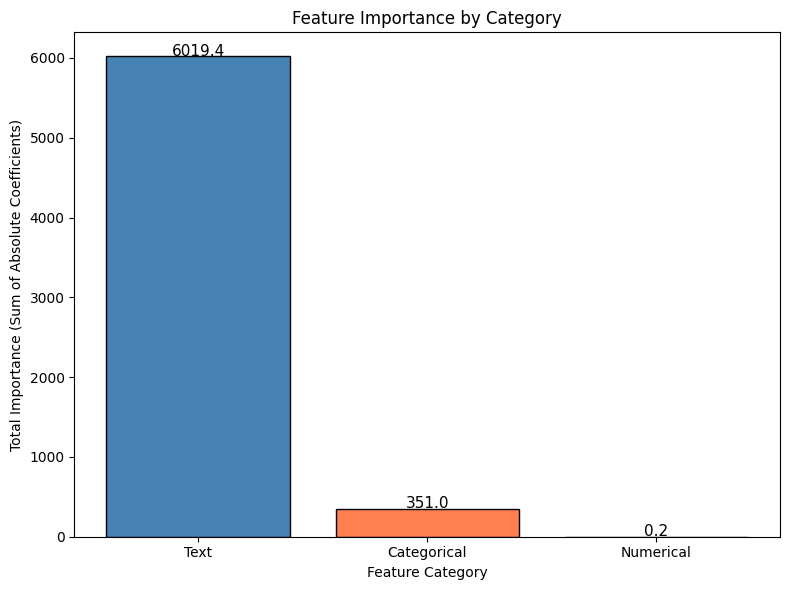

In [110]:
# Feature Importance by Category
importance_df['category'] = 'Text'
importance_df.loc[importance_df['feature'].isin(numerical_feature_names), 'category'] = 'Numerical'
importance_df.loc[importance_df['feature'].isin(categorical_feature_names), 'category'] = 'Categorical'

# Sum importance by category
category_importance = importance_df.groupby('category')['importance'].sum().sort_values(ascending=False)
print("Total Feature Importance by Category:")
print(category_importance)

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'coral', 'green']
ax.bar(category_importance.index, category_importance.values, color=colors, edgecolor='black')
ax.set_xlabel('Feature Category')
ax.set_ylabel('Total Importance (Sum of Absolute Coefficients)')
ax.set_title('Feature Importance by Category')
for i, v in enumerate(category_importance.values):
    ax.text(i, v + 5, f'{v:.1f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

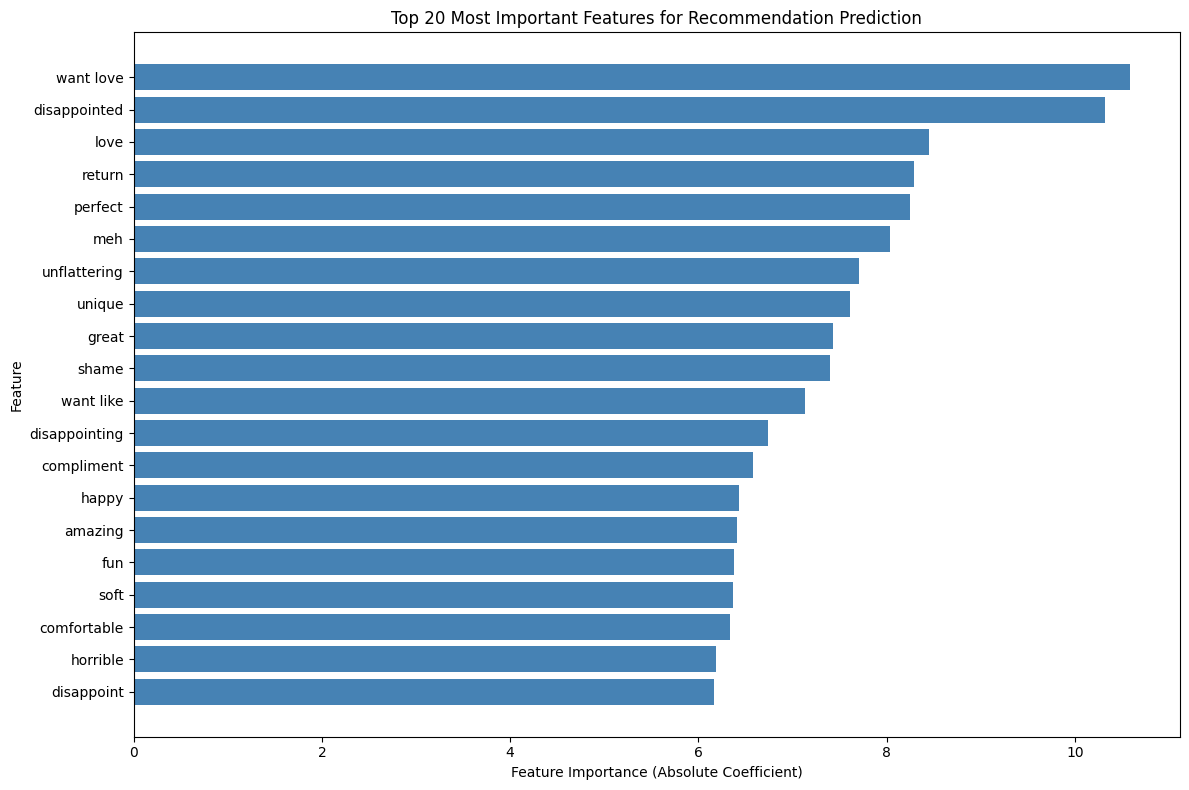

In [111]:
# Visualize Top 20 Most Important Features
plt.figure(figsize=(12, 8))
top_20 = importance_df.head(20)
plt.barh(range(len(top_20)), top_20['importance'].values, color='steelblue')
plt.yticks(range(len(top_20)), top_20['feature'].values)
plt.xlabel('Feature Importance (Absolute Coefficient)')
plt.ylabel('Feature')
plt.title('Top 20 Most Important Features for Recommendation Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Save Model for Deployment

Save the trained model as a pickle file for later use.

In [112]:
# Save the trained model as a pickle file for deployment
import pickle
import os

# Create the models directory if it doesn't exist
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# Save the best model
model_path = os.path.join(models_dir, 'recommendation_pipeline.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

print(f"Model saved to: {model_path}")

# Also save the feature importance data
importance_path = os.path.join(models_dir, 'feature_importance.csv')
importance_df.to_csv(importance_path, index=False)
print(f"Feature importance saved to: {importance_path}")

Model saved to: models\recommendation_pipeline.pkl
Feature importance saved to: models\feature_importance.csv


In [115]:
# Demo: Load and use the saved model
print("=" * 50)
print("Demo: Loading and using the saved model")
print("=" * 50)

# Load the saved model
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

# Create a sample review for prediction
sample_review = pd.DataFrame({
    'Clothing ID': [1077],
    'Age': [35],
    'Title': ['Love this dress!'],
    'Review Text': ['This dress is absolutely beautiful and fits perfectly. Great quality!'],
    'Positive Feedback Count': [5],
    'Division Name': ['General'],
    'Department Name': ['Dresses'],
    'Class Name': ['Dresses']
})

# Make prediction
prediction = loaded_model.predict(sample_review)
probability = loaded_model.predict_proba(sample_review)

print(f"\nSample Review: {sample_review['Title'].values[0]}")
print(f"Review Text: {sample_review['Review Text'].values[0][:50]}...")
print(f"\nPrediction: {'Recommended' if prediction[0] == 1 else 'Not Recommended'}")
print(f"Probability: Not Recommended: {probability[0][0]:.2%}, Recommended: {probability[0][1]:.2%}")

Demo: Loading and using the saved model

Sample Review: Love this dress!
Review Text: This dress is absolutely beautiful and fits perfec...

Prediction: Recommended
Probability: Not Recommended: 0.64%, Recommended: 99.36%
